# Geospatial Machine Learning — Part 3: Random Forest Regression

This notebook trains a **Random Forest** model to predict topsoil sand content (%, 0–50 cm) from environmental rasters, evaluates it, and applies it to the rasters to produce a **sand-content map of Brazil**.

**Random Forest** is an ensemble of many decision trees. Each tree is trained on a bootstrap sample of the data and, at each split, considers only a random subset of the predictors. The final prediction is the average of all trees. It handles non-linear relationships and interactions between predictors without requiring the analyst to specify them.

**Validation strategy.** The data are split *randomly* into 70 % training and 30 % independent test, and the hyperparameters are tuned with *random* 10-fold cross-validation. Because sand content is spatially autocorrelated (Part 2), random splits place test samples very close to training samples. The metrics obtained here are therefore likely **optimistic**; Part 4 repeats the analysis with spatial cross-validation for comparison.

**Workflow**

1. Load the sample data
2. Load the raster predictors
3. Extract raster values at sample locations
4. Prepare the modeling dataset
5. Split the data into training and test sets
6. Define 10-fold cross-validation
7. Train and tune a Random Forest regression model
8. Evaluate cross-validation performance
9. Examine variable importance
10. Predict the independent test data
11. Evaluate the independent test data
12. Compare observed and predicted values
13. Apply the model to the raster predictors and save the prediction map
14. Display the prediction map

The prediction map is saved to the `output` folder.

In [1]:
# Import libraries for vector data, raster data, machine learning,
# data manipulation, plotting, and model evaluation.

from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.windows import Window
from rasterio.transform import rowcol
from rasterio.windows import transform as window_transform
from rasterio.mask import mask
from rasterio.merge import merge

import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, KFold, cross_val_predict, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance

## 1. Load the sample data

Samples made only of coarse fragments (`esqueleto` = 1000 g/kg) are removed, because their sand value of 0 is not a real measurement.

In [2]:
# Input data and outputs are kept in separate folders next to this notebook.
INPUT_DIR = Path("input")
OUTPUT_DIR = Path("output")

# Define the path to the point dataset containing the response variable.
samples_path = INPUT_DIR / "c3_soildata_psd_modeling_0_50cm.gpkg"

# Read the point dataset as a GeoDataFrame.
samples = gpd.read_file(samples_path)

# Drop layers made only of coarse fragments (esqueleto = 1000 g/kg).
# They contain no fine earth, so sand = 0 there is not a measurement.
samples = samples[samples["esqueleto"] < 1000].reset_index(drop=True)
print("Samples after removing esqueleto = 1000:", len(samples))

# Inspect the sample data.
samples.info()
display(samples.head())
display(samples.describe(include="all"))

Samples after removing esqueleto = 1000: 14165
<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 14165 entries, 0 to 14164
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   id                        14165 non-null  str     
 1   longitude                 14165 non-null  float64 
 2   latitude                  14165 non-null  float64 
 3   profundidade              14165 non-null  float64 
 4   esqueleto                 14165 non-null  int32   
 5   areia                     14165 non-null  int32   
 6   silte                     14165 non-null  int32   
 7   argila                    14165 non-null  int32   
 8   log_silte1p_argila1p      14165 non-null  float64 
 9   log_areia1p_argila1p      14165 non-null  float64 
 10  log_esqueleto1p_argila1p  14165 non-null  float64 
 11  geometry                  14165 non-null  geometry
dtypes: float64(6), geometry(1), int32(4), str(1)
me

,id,longitude,latitude,profundidade,esqueleto,areia,silte,argila,log_silte1p_argila1p,log_areia1p_argila1p,log_esqueleto1p_argila1p,geometry
0,clay-copy-ctb0004-RosĂˇrio-26,-35.134160,-8.576835,40.0,0,200,150,650,-1.461230,-1.175205,-6.478510,POINT (-35.13416 -8.57683)
1,clay-copy-ctb0019-P1,-50.231766,-29.475679,44.0,0,120,250,630,-0.921853,-1.651515,-6.447306,POINT (-50.23177 -29.47568)
2,clay-copy-ctb0033-RO1271,-64.059444,-11.770000,50.0,0,157,67,776,-2.435933,-1.592845,-6.655440,POINT (-64.05944 -11.77)
3,clay-copy-ctb0033-RO1279,-64.330278,-12.018333,45.0,0,60,200,740,-1.304696,-2.497127,-6.608001,POINT (-64.33028 -12.01833)
4,clay-copy-ctb0033-RO1303,-63.941667,-9.891667,45.0,400,260,70,670,-2.237736,-0.942691,-0.004975,POINT (-63.94167 -9.89167)


,id,longitude,latitude,profundidade,esqueleto,areia,silte,argila,log_silte1p_argila1p,log_areia1p_argila1p,log_esqueleto1p_argila1p,geometry
count,14165,14165.000000,14165.000000,14165.000000,14165.000000,14165.000000,14165.000000,14165.000000,14165.000000,14165.000000,14165.000000,14165
unique,14057,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14165
top,clay-copy-ctb0033-RO2493,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (-35.13416003624 -8.576834933487826)
freq,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
mean,NaN,-53.621213,-16.082803,24.697653,64.939287,484.000424,182.003318,333.996258,-0.627611,0.498344,-3.082999,NaN
std,NaN,8.079586,8.481977,14.933753,110.124817,277.086129,140.243171,215.486282,0.918257,1.954324,2.578236,NaN
min,NaN,-73.850000,-33.686969,0.500000,0.000000,0.000000,0.000000,0.000000,-6.673298,-6.792344,-6.888572,NaN
25%,NaN,-61.150000,-22.501390,10.000000,0.000000,249.000000,77.000000,150.000000,-1.252763,-0.660357,-5.564520,NaN
50%,NaN,-54.150000,-15.936090,22.500000,10.000000,483.000000,144.000000,300.000000,-0.707513,0.423050,-3.209306,NaN
75%,NaN,-47.316670,-9.900021,39.000000,118.000000,710.000000,260.000000,492.000000,0.000000,1.474801,-0.796944,NaN


## 2. Load the raster predictors

Every GeoTIFF in the `input` folder is used as a predictor, and its file name becomes the variable name. The same names are used later to match model variables to raster files when the map is produced.

In [3]:
# Define the directory containing the predictor rasters.
workdir_xvars = INPUT_DIR

# List all GeoTIFF files in the predictor directory.
raster_files = sorted(workdir_xvars.glob("*.tif"))

print(f"Number of raster predictors: {len(raster_files)}")
for f in raster_files:
    print(f.name)

Number of raster predictors: 25
HAND.tif
Mean_curvature.tif
NTSI.tif
TPI_11x11.tif
bio1.tif
bio10.tif
bio11.tif
bio12.tif
bio13.tif
bio14.tif
bio15.tif
bio16.tif
bio17.tif
bio18.tif
bio19.tif
bio2.tif
bio3.tif
bio4.tif
bio5.tif
bio6.tif
bio7.tif
bio8.tif
bio9.tif
elevation.tif
slope.tif


In [4]:
# Read raster layer names from file stems.
# These names must match the predictor columns used by the model.
raster_names = [f.stem for f in raster_files]

raster_names

['HAND',
 'Mean_curvature',
 'NTSI',
 'TPI_11x11',
 'bio1',
 'bio10',
 'bio11',
 'bio12',
 'bio13',
 'bio14',
 'bio15',
 'bio16',
 'bio17',
 'bio18',
 'bio19',
 'bio2',
 'bio3',
 'bio4',
 'bio5',
 'bio6',
 'bio7',
 'bio8',
 'bio9',
 'elevation',
 'slope']

## 3. Extract raster values at sample locations

The value of each raster is read at each sample point, producing one column per predictor.

In [5]:
# Check the coordinate reference system of the samples and rasters.
with rasterio.open(raster_files[0]) as src:
    raster_crs = src.crs

print("Sample CRS:", samples.crs)
print("Raster CRS:", raster_crs)

# Reproject sample points if necessary.
if samples.crs != raster_crs:
    samples = samples.to_crs(raster_crs)

Sample CRS: EPSG:4326
Raster CRS: EPSG:4326


In [6]:
# Extract raster values at each sample location.
# One new column is created for each raster predictor.

coords = [(geom.x, geom.y) for geom in samples.geometry]

for raster_path, raster_name in zip(raster_files, raster_names):
    with rasterio.open(raster_path) as src:
        values = [v[0] for v in src.sample(coords)]

        # Convert raster nodata values to NaN.
        if src.nodata is not None:
            values = [
                np.nan if v == src.nodata else v
                for v in values
            ]

        samples[raster_name] = values

display(samples.head())

,id,longitude,latitude,profundidade,esqueleto,areia,silte,argila,log_silte1p_argila1p,log_areia1p_argila1p,...,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,elevation,slope
0,clay-copy-ctb0004-RosĂˇrio-26,-35.134160,-8.576835,40.0,0,200,150,650,-1.461230,-1.175205,...,6.566667,69.122803,105.115379,29.000000,19.500000,9.500000,23.566666,24.783333,36.0,0.960910
1,clay-copy-ctb0019-P1,-50.231766,-29.475679,44.0,0,120,250,630,-0.921853,-1.651515,...,8.783334,51.364521,305.108032,23.600000,6.500000,17.100000,18.783333,15.983334,916.0,0.110330
2,clay-copy-ctb0033-RO1271,-64.059444,-11.770000,50.0,0,157,67,776,-2.435933,-1.592845,...,11.125000,73.190796,67.367989,33.099998,17.900000,15.199999,26.150000,25.166666,158.0,0.515958
3,clay-copy-ctb0033-RO1279,-64.330278,-12.018333,45.0,0,60,200,740,-1.304696,-2.497127,...,10.850000,73.809525,69.870026,33.000000,18.299999,14.700001,26.366667,25.333334,148.0,0.137899
4,clay-copy-ctb0033-RO1303,-63.941667,-9.891667,45.0,400,260,70,670,-2.237736,-0.942691,...,11.691667,72.619049,53.262882,33.500000,17.400000,16.100000,25.783333,25.100000,163.0,0.343252


## 4. Prepare the modeling dataset

Only the response (`areia`) and the raster predictors are kept. Samples with any missing predictor value are removed, because scikit-learn's Random Forest does not accept missing values. Sand content is then converted from g/kg to %.

In [7]:
# Remove geometry and variables that will not be used as predictors.
columns_to_remove = [
    "id",
    "longitude",
    "latitude",
    "profundidade",
    "esqueleto",
    "silte",
    "argila",
    "log_silte1p_argila1p",
    "log_areia1p_argila1p",
    "log_esqueleto1p_argila1p",
]

samples_df = samples.drop(columns="geometry").copy()

samples_df = samples_df.drop(
    columns=[c for c in columns_to_remove if c in samples_df.columns]
)

print("Number of samples before removing NA:", len(samples_df))

# Remove observations with missing values in the response or predictors.
samples_df = samples_df.dropna().copy()

print("Number of complete samples:", len(samples_df))

display(samples_df.head())
display(samples_df.describe())

Number of samples before removing NA: 14165
Number of complete samples: 13636


,areia,HAND,Mean_curvature,NTSI,TPI_11x11,bio1,bio10,bio11,bio12,bio13,...,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,elevation,slope
0,200,29.005001,-4.573328e-06,0.000083,-6.528925,24.391666,25.516666,22.983334,2119.0,328.0,...,6.566667,69.122803,105.115379,29.000000,19.500000,9.500000,23.566666,24.783333,36.0,0.960910
1,120,773.000000,9.522858e-06,-0.001479,173.289261,14.950000,18.783333,11.350000,1997.0,191.0,...,8.783334,51.364521,305.108032,23.600000,6.500000,17.100000,18.783333,15.983334,916.0,0.110330
2,157,0.000000,-8.854991e-06,0.005365,-16.669422,25.970833,26.666666,24.983334,1583.0,253.0,...,11.125000,73.190796,67.367989,33.099998,17.900000,15.199999,26.150000,25.166666,158.0,0.515958
3,60,0.000000,-2.143425e-07,0.003746,-11.256198,26.200001,26.950001,25.200001,1555.0,251.0,...,10.850000,73.809525,69.870026,33.000000,18.299999,14.700001,26.366667,25.333334,148.0,0.137899
4,260,38.011002,6.404418e-07,-0.003907,-0.975207,25.712500,26.283335,24.966667,2036.0,320.0,...,11.691667,72.619049,53.262882,33.500000,17.400000,16.100000,25.783333,25.100000,163.0,0.343252


,areia,HAND,Mean_curvature,NTSI,TPI_11x11,bio1,bio10,bio11,bio12,bio13,...,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,elevation,slope
count,13636.000000,13636.000000,1.363600e+04,13636.000000,13636.000000,13636.000000,13636.000000,13636.000000,13636.000000,13636.000000,...,13636.000000,13636.000000,13636.000000,13636.000000,13636.000000,13636.000000,13636.000000,13636.000000,13636.000000,13636.000000
mean,470.836169,109.073753,3.513821e-07,0.001952,1.799722,22.960907,24.806702,20.749161,1645.977295,253.691849,...,11.321078,66.241867,170.198074,31.237543,13.846582,17.390957,23.347353,21.724951,361.772954,1.190148
std,269.057196,152.347961,2.467508e-05,0.009556,44.347252,3.126982,2.088981,4.399317,394.786865,69.592743,...,1.385623,8.933483,118.877693,2.453016,4.310484,2.904920,3.428816,4.010433,311.814036,1.559417
min,0.000000,0.000000,-1.851026e-04,-0.064239,-389.107452,9.283334,11.466667,6.766666,379.000000,64.000000,...,6.216667,40.659340,23.880211,16.600000,-1.300000,9.099998,10.933333,6.766666,1.000000,0.000000
25%,240.000000,20.000000,-7.082996e-06,-0.001158,-13.090909,20.045834,23.700001,16.799999,1457.000000,190.000000,...,10.475000,61.056914,64.402494,30.200001,9.900000,15.900000,22.266666,18.816668,132.000000,0.321978
50%,471.500000,50.001999,6.856626e-12,0.001107,-0.421488,24.004168,25.200001,22.408334,1634.000000,262.000000,...,11.500000,68.404625,156.166199,31.700001,14.600000,18.100000,24.733334,22.850000,243.500000,0.689051
75%,690.000000,136.003242,8.164782e-06,0.002972,14.274793,25.370832,26.283333,24.466667,1853.000000,311.000000,...,12.441667,71.421265,235.627792,33.200001,17.000000,19.100002,25.666666,24.783333,530.000000,1.369471
max,1000.000000,2046.005981,2.857003e-04,0.157383,591.388428,28.066666,29.483334,27.266666,3624.000000,585.000000,...,15.208334,90.591385,461.137207,36.400002,22.900000,24.200001,28.166666,28.466667,2666.000000,17.405693


In [8]:
# Convert sand content to percent.
samples_df["areia"] = samples_df["areia"] / 10

## 5. Split the data into training and test sets

30 % of the samples are set aside as an **independent test set**. They are not used for training or tuning, only for the final evaluation.

In [9]:
# Separate response and predictors.
X = samples_df.drop(columns="areia")
y = samples_df["areia"]

# Split the data into 70% training and 30% independent test data.
# A fixed random state makes the split reproducible.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=123
)

print("Training samples:", len(X_train))
print("Test samples:", len(X_test))

Training samples: 9545
Test samples: 4091


## 6. Define the cross-validation strategy

Within the training set, 10-fold cross-validation splits the data into 10 random parts; each part is predicted by a model trained on the other 9. This is used to choose hyperparameters and to estimate performance without touching the test set.

In [10]:
# Configure 10-fold cross-validation.
cv = KFold(
    n_splits=10,
    shuffle=True,
    random_state=123
)

## 7. Train and tune the Random Forest model

Two hyperparameters are tuned with a grid search:

- `max_features`: how many predictors each split may consider (`"sqrt"` = √25 ≈ 5, `0.5` = half, `1.0` = all);
- `min_samples_leaf`: minimum number of samples in a terminal leaf (larger values give smoother predictions).

The combination with the lowest cross-validation RMSE is refitted on the whole training set.

In [11]:
# Define a Random Forest regression model.
model_rf = RandomForestRegressor(
    n_estimators=200,
    max_features="sqrt",
    min_samples_leaf=5,
    random_state=123,
    n_jobs=-1
)

# Define a small hyperparameter grid similar to caret/ranger tuning.
param_grid = {
    "max_features": ["sqrt", 0.5, 1.0],
    "min_samples_leaf": [3, 5]
}

# Tune hyperparameters using 10-fold cross-validation.
# RMSE is used to select the best model.
grid_search = GridSearchCV(
    estimator=model_rf,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

model_rf = grid_search.best_estimator_

print("Best parameters:")
print(grid_search.best_params_)

print("\nBest cross-validation RMSE:")
print(-grid_search.best_score_)

Fitting 10 folds for each of 6 candidates, totalling 60 fits
Best parameters:
{'max_features': 0.5, 'min_samples_leaf': 3}

Best cross-validation RMSE:
17.40918925942856


## 8. Evaluate cross-validation performance

Out-of-fold predictions (each sample predicted by the model that did not see it) are compared with the observed values:

- **RMSE** (root mean squared error) and **MAE** (mean absolute error), both in sand percentage points;
- **R²**, the proportion of the variance of sand content explained by the model.

In [12]:
# Generate out-of-fold predictions for the selected model.
pred_cv = cross_val_predict(
    model_rf,
    X_train,
    y_train,
    cv=cv,
    n_jobs=-1
)

# Calculate cross-validation performance metrics.
rmse_cv = mean_squared_error(y_train, pred_cv) ** 0.5
mae_cv = mean_absolute_error(y_train, pred_cv)
r2_cv = r2_score(y_train, pred_cv)

metrics_cv = pd.DataFrame({
    "Metric": ["RMSE", "MAE", "R²"],
    "Value": [rmse_cv, mae_cv, r2_cv]
})

display(metrics_cv)

,Metric,Value
0,RMSE,17.412692
1,MAE,12.982798
2,R²,0.580332


## 9. Examine variable importance

**Permutation importance** measures how much the model's score drops when the values of one predictor are randomly shuffled. A large drop means the model relies on that variable.

Note: importance is computed on the training data and is shared among correlated predictors (e.g. the temperature-related `bio` variables), so it shows what the model uses, not necessarily what causes sand content.

In [13]:
# Calculate permutation importance using the training data.
perm_importance = permutation_importance(
    model_rf,
    X_train,
    y_train,
    n_repeats=10,
    random_state=123,
    n_jobs=-1
)

importance_df = pd.DataFrame({
    "Variable": X_train.columns,
    "Importance": perm_importance.importances_mean
}).sort_values(
    "Importance",
    ascending=False
)

display(importance_df.head(20))

,Variable,Importance
2,NTSI,0.280029
7,bio12,0.122248
19,bio6,0.106268
17,bio4,0.097983
22,bio9,0.083746
20,bio7,0.082308
13,bio18,0.078131
15,bio2,0.062228
16,bio3,0.059058
10,bio15,0.058723


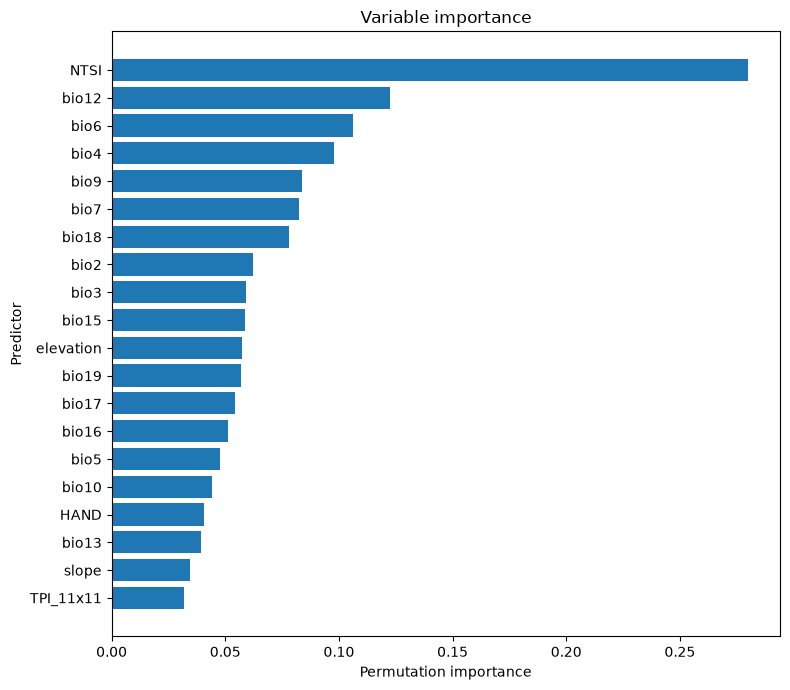

In [14]:
# Plot the 20 most important predictors.
top_imp = importance_df.head(20).sort_values("Importance")

plt.figure(figsize=(8, 7))
plt.barh(top_imp["Variable"], top_imp["Importance"])
plt.xlabel("Permutation importance")
plt.ylabel("Predictor")
plt.title("Variable importance")
plt.tight_layout()
plt.show()

## 10. Predict the independent test data

The tuned model predicts the 30 % of samples that were held out from the start.

In [15]:
# Predict sand content for observations that were not used
# during model training or cross-validation.
pred_test = model_rf.predict(X_test)

## 11. Evaluate the independent test data

The test metrics (RMSE ≈ 17.3 %, R² ≈ 0.59) are very close to the cross-validation metrics (RMSE ≈ 17.4 %, R² ≈ 0.58): the model generalizes well to new samples *drawn from the same spatial pattern*. However, because both evaluations use random splits, most test samples lie within a few kilometers of a training sample (the variogram range is ~6 km, Part 2). Neither evaluation tests prediction in regions far from the training data; this is done in Part 4.

In [16]:
# Calculate independent validation metrics.
rmse_test = mean_squared_error(y_test, pred_test) ** 0.5
mae_test = mean_absolute_error(y_test, pred_test)
r2_test = r2_score(y_test, pred_test)

metrics_test = pd.DataFrame({
    "Dataset": ["Independent test"],
    "RMSE": [rmse_test],
    "R2": [r2_test],
    "MAE": [mae_test]
})

display(metrics_test)

,Dataset,RMSE,R2,MAE
0,Independent test,17.285831,0.588873,12.89525


## 12. Compare observed and predicted values

Points on the dashed 1:1 line are perfect predictions. A cloud flatter than the 1:1 line is typical of Random Forest: averaging many trees pulls predictions toward the mean, so high sand contents are underestimated and low ones overestimated.

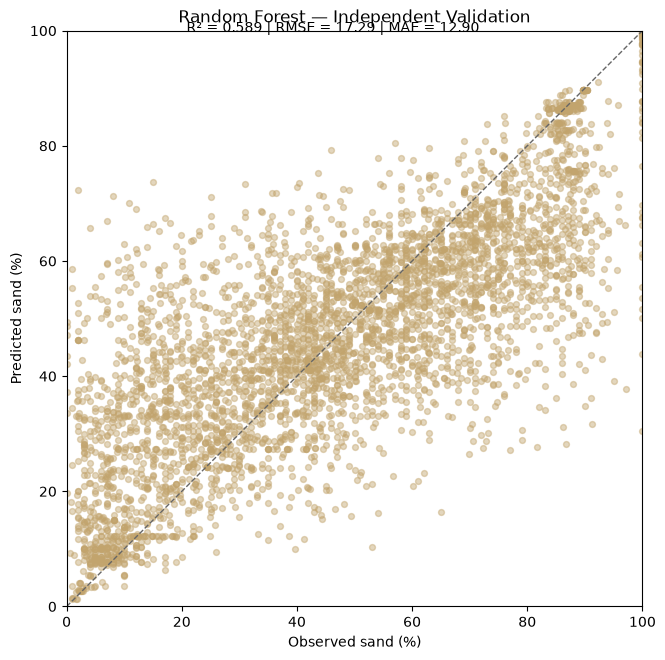

In [17]:
# Define common axis limits from both observed and predicted values.
lims = [
    min(y_test.min(), pred_test.min()),
    max(y_test.max(), pred_test.max())
]

# Plot observed versus predicted sand content.
# Smaller points and partial transparency help reveal point overlap.
plt.figure(figsize=(7, 7))

plt.scatter(
    y_test,
    pred_test,
    s=18,
    alpha=0.45,
    c="#C2A46D"
)

plt.plot(
    lims,
    lims,
    linestyle="--",
    linewidth=1.0,
    color="0.4"
)

plt.xlim(lims)
plt.ylim(lims)
plt.gca().set_aspect("equal", adjustable="box")

plt.xlabel("Observed sand (%)")
plt.ylabel("Predicted sand (%)")
plt.title("Random Forest — Independent Validation")
plt.suptitle(
    f"R² = {r2_test:.3f} | RMSE = {rmse_test:.2f} | MAE = {mae_test:.2f}",
    y=0.92,
    fontsize=10
)

plt.tight_layout()
plt.show()

## 13. Apply the model to the raster predictors

To produce a map, the model is applied to every pixel. The steps are:

1. match each model variable to its raster file;
2. check that all rasters share the same grid (size, geotransform and CRS), so the same pixel refers to the same location in every layer;
3. read the rasters block by block (to avoid loading all layers into memory at once), predict the pixels where every predictor is valid, and write the result to `output/pred_areia_rf.tif`.

In [18]:
# Identify the predictor names used during model training.
predictor_names = list(X_train.columns)

# Match predictor names to raster files.
raster_lookup = {f.stem: f for f in raster_files}

missing_vars = [
    name for name in predictor_names
    if name not in raster_lookup
]

if missing_vars:
    raise ValueError(
        "Missing raster predictors: " + ", ".join(missing_vars)
    )

predictor_rasters = [
    raster_lookup[name]
    for name in predictor_names
]

predictor_rasters

[PosixPath('input/HAND.tif'),
 PosixPath('input/Mean_curvature.tif'),
 PosixPath('input/NTSI.tif'),
 PosixPath('input/TPI_11x11.tif'),
 PosixPath('input/bio1.tif'),
 PosixPath('input/bio10.tif'),
 PosixPath('input/bio11.tif'),
 PosixPath('input/bio12.tif'),
 PosixPath('input/bio13.tif'),
 PosixPath('input/bio14.tif'),
 PosixPath('input/bio15.tif'),
 PosixPath('input/bio16.tif'),
 PosixPath('input/bio17.tif'),
 PosixPath('input/bio18.tif'),
 PosixPath('input/bio19.tif'),
 PosixPath('input/bio2.tif'),
 PosixPath('input/bio3.tif'),
 PosixPath('input/bio4.tif'),
 PosixPath('input/bio5.tif'),
 PosixPath('input/bio6.tif'),
 PosixPath('input/bio7.tif'),
 PosixPath('input/bio8.tif'),
 PosixPath('input/bio9.tif'),
 PosixPath('input/elevation.tif'),
 PosixPath('input/slope.tif')]

In [19]:
# Check that all predictor rasters share the same grid.
reference_path = predictor_rasters[0]

with rasterio.open(reference_path) as ref:
    ref_profile = ref.profile.copy()
    ref_shape = (ref.height, ref.width)
    ref_transform = ref.transform
    ref_crs = ref.crs

for path in predictor_rasters[1:]:
    with rasterio.open(path) as src:
        if (src.height, src.width) != ref_shape:
            raise ValueError(f"Raster shape mismatch: {path.name}")
        # Compare with a tolerance: some rasters differ from the reference only by
        # floating-point noise in the geotransform (~1e-7 degrees, far below one pixel).
        if not src.transform.almost_equals(ref_transform, precision=1e-6):
            raise ValueError(f"Raster transform mismatch: {path.name}")
        if src.crs != ref_crs:
            raise ValueError(f"Raster CRS mismatch: {path.name}")

print("All predictor rasters share the same grid.")

All predictor rasters share the same grid.


In [20]:
# Predict the raster in blocks to avoid loading the full stack into memory.
output_path = OUTPUT_DIR / "pred_areia_rf.tif"

output_path.parent.mkdir(
    parents=True,
    exist_ok=True
)

with rasterio.open(reference_path) as ref:
    profile = ref.profile.copy()

profile.update(
    count=1,
    dtype="float32",
    nodata=np.nan,
    compress="deflate",
    predictor=3,
    zlevel=9
)

sources = [
    rasterio.open(path)
    for path in predictor_rasters
]

try:
    with rasterio.open(output_path, "w", **profile) as dst:

        for _, window in sources[0].block_windows(1):

            arrays = []
            valid_mask = None

            for src in sources:
                arr = src.read(
                    1,
                    window=window
                ).astype("float32")

                current_valid = np.isfinite(arr)

                if src.nodata is not None:
                    current_valid &= arr != src.nodata

                valid_mask = (
                    current_valid
                    if valid_mask is None
                    else valid_mask & current_valid
                )

                arrays.append(arr)

            block_shape = arrays[0].shape
            output_block = np.full(
                block_shape,
                np.nan,
                dtype="float32"
            )

            if np.any(valid_mask):
                X_block = np.column_stack([
                    arr[valid_mask]
                    for arr in arrays
                ])

                pred_block = model_rf.predict(
                    pd.DataFrame(
                        X_block,
                        columns=predictor_names
                    )
                )

                output_block[valid_mask] = pred_block.astype("float32")

            dst.write(
                output_block,
                1,
                window=window
            )

finally:
    for src in sources:
        src.close()

print(f"Prediction saved to: {output_path}")

/tmp/ipykernel_1182/1998298342.py:35: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  arr = src.read(
/tmp/ipykernel_1182/1998298342.py:35: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  arr = src.read(
/tmp/ipykernel_1182/1998298342.py:35: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  arr = src.read(
/tmp/ipykernel_1182/1998298342.py:35: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  arr = src.read(
/tmp/ipykernel_1182/1998298342.py:35: DeprecationWarning

Prediction saved to: output/pred_areia_rf.tif


/tmp/ipykernel_1182/1998298342.py:35: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  arr = src.read(


## 14. Display the prediction map

Predicted sand content (%) for every pixel where all predictors are available.

/tmp/ipykernel_1182/1400511626.py:3: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  pred_map = src.read(1)


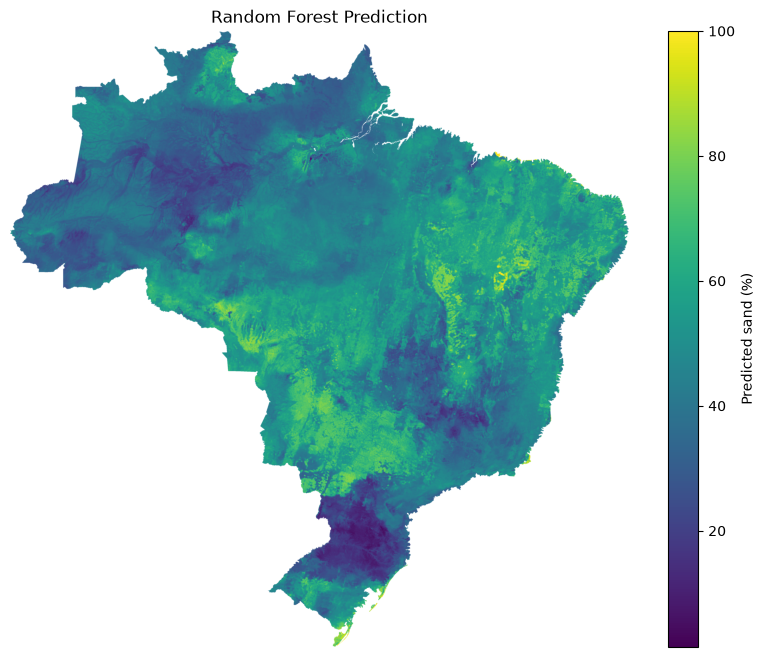

In [21]:
# Display the predicted sand-content raster.
with rasterio.open(output_path) as src:
    pred_map = src.read(1)

plt.figure(figsize=(10, 8))
plt.imshow(pred_map)
plt.colorbar(label="Predicted sand (%)")
plt.title("Random Forest Prediction")
plt.axis("off")
plt.show()

## Summary

- The tuned Random Forest (`max_features = 0.5`, `min_samples_leaf = 3`) explains about **58–59 % of the variance** of sand content, with an error of about **17 percentage points** (RMSE), both in cross-validation and on the independent test.
- `NTSI` is by far the most important predictor, followed by precipitation and temperature-seasonality variables (`bio12`, `bio6`, `bio4`).
- These metrics come from **random** splits and are likely optimistic for unsampled regions. Compare them with the spatial validation in Part 4.